# Data & Metadata Verification — DMR-IR Breast Thermography Cohort

**Purpose.** Single source of truth for the thesis *Data & Methods* chapter:

1. Total patients in the source dataset and their class / split distribution.
2. The **funnel** that reduces the raw dataset to the **122 patients** actually solvable by the FEM (5 complete IR views + 5 segmentation masks).
3. Per-view completeness (why 15 patients are dropped).
4. Clinical metadata needed by the bioheat model (body temperature → chest-wall BC).
5. An explicit **FEM input checklist** — every quantity the forward/inverse solver consumes, and whether we actually have it.

All figures are written to `results/thesis_figures/` at 300 dpi for direct inclusion in the thesis.


In [1]:
import os, sys, json, math
from pathlib import Path
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- resolve repo root whether run from repo/ or repo/TherMAM-NeRF/ ---
HERE = Path.cwd()
REPO = HERE
for cand in [HERE, HERE.parent, *HERE.parents]:
    if (cand / 'data' / 'organized_by_patient').exists():
        REPO = cand; break
print('Repo root:', REPO)

MANIFEST   = REPO / 'FailedExperiments' / 'patient_manifest.csv'
TIFF_DIR   = REPO / 'data' / 'organized_by_patient'
UNET_DIR   = REPO / 'data' / 'organized_by_patient_unet'
COHORT_CSV = REPO / 'TherMAM-NeRF' / 'results' / 'cohort_femfem_all.csv'
FIG_DIR    = REPO / 'TherMAM-NeRF' / 'results' / 'thesis_figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

for p in [MANIFEST, TIFF_DIR, UNET_DIR]:
    print(f'{"OK " if p.exists() else "MISSING"} {p}')

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    plt.style.use('seaborn-whitegrid' if 'seaborn-whitegrid' in plt.style.available else 'default')
BENIGN_C, MALIG_C = '#4C72B0', '#C44E52'
def save(fig, name):
    fig.tight_layout(); fig.savefig(FIG_DIR / name, dpi=300, bbox_inches='tight')
    print('saved →', FIG_DIR / name)


Repo root: /mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR
OK  /mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/FailedExperiments/patient_manifest.csv
OK  /mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/data/organized_by_patient
OK  /mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/data/organized_by_patient_unet


## 1. Source dataset — total patients, class & split distribution

`patient_manifest.csv` is the materialised metadata of the HuggingFace `SemilleroCV/DMR-IR` dataset — **one row per patient**, the complete cohort before any geometry/mesh filtering.


In [2]:
man = pd.read_csv(MANIFEST)
print('Total patients in source manifest:', len(man))
print()
print('Class distribution:'); print(man['label'].value_counts())
print()
print('Split distribution:'); print(man['split'].value_counts())
print()
print('Columns:', list(man.columns))
man.head(3)


Total patients in source manifest: 268

Class distribution:
label
benign       171
malignant     97
Name: count, dtype: int64

Split distribution:
split
train         188
test           40
validation     40
Name: count, dtype: int64

Columns: ['patient_id', 'split', 'label', 'n_total_images', 'n_static_views', 'n_dynamic_frames', 'has_seg_mask', 'ready_stereo', 'ready_dynamic', 'ready_full_pipeline', 'idx_frontal', 'idx_right_45', 'idx_right_90', 'idx_left_45', 'idx_left_90', 'dynamic_idx_list', 'age_at_visit', 'body_temperature', 'menopause', 'cancer_family', 'biopsy', 'mammography', 'complaints', 'symptoms', 'signs', 'further_informations', 'medical_further_informations', 'text']


,patient_id,split,label,n_total_images,n_static_views,n_dynamic_frames,has_seg_mask,ready_stereo,ready_dynamic,ready_full_pipeline,...,menopause,cancer_family,biopsy,mammography,complaints,symptoms,signs,further_informations,medical_further_informations,text
0,1,train,benign,12,5,0,True,True,False,False,...,NaN,NaN,0.0,1.0,NaN,NaN,NaN,NaN,NaN,Patient is 63 years old and identifies as mult...
1,10,test,benign,27,5,0,True,True,False,False,...,NaN,NaN,1.0,1.0,nodules,NaN,does not feel any palpable lump,NaN,NaN,Patient is 42 years old and identifies as blac...
2,100,train,benign,27,5,0,True,True,False,False,...,NaN,NaN,0.0,1.0,No,NaN,Yes,NaN,NaN,Patient is 63 years old and identifies as mult...


saved → /mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/TherMAM-NeRF/results/thesis_figures/fig1_source_class_split.png


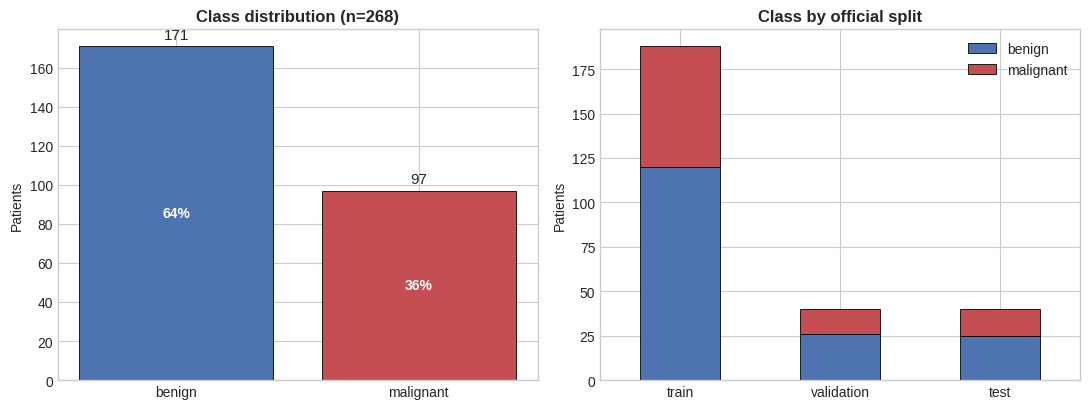

In [3]:
# --- Figure 1: class + split distribution of the full source cohort ---
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

cls = man['label'].value_counts()
colors = [BENIGN_C if l == 'benign' else MALIG_C for l in cls.index]
b = ax[0].bar(cls.index, cls.values, color=colors, edgecolor='black', linewidth=.6)
ax[0].bar_label(b, padding=3, fontsize=11)
ax[0].set_title(f'Class distribution (n={len(man)})', fontweight='bold')
ax[0].set_ylabel('Patients')
total = len(man)
for rect, v in zip(b, cls.values):
    ax[0].text(rect.get_x()+rect.get_width()/2, v/2, f'{100*v/total:.0f}%',
               ha='center', va='center', color='white', fontweight='bold')

sp = man.groupby(['split', 'label']).size().unstack(fill_value=0)
sp = sp.reindex(['train', 'validation', 'test'])
sp.plot(kind='bar', stacked=True, ax=ax[1],
        color=[BENIGN_C, MALIG_C], edgecolor='black', linewidth=.6)
ax[1].set_title('Class by official split', fontweight='bold')
ax[1].set_ylabel('Patients'); ax[1].set_xlabel('')
ax[1].tick_params(axis='x', rotation=0); ax[1].legend(title='')
save(fig, 'fig1_source_class_split.png'); plt.show()


## 2. The funnel — from 268 source patients to the 122 the FEM can solve

The forward/inverse FEM needs a **watertight 3-D breast mesh**, which the TherMAM-NeRF reconstruction builds from **all 5 static IR views + their 5 segmentation masks**. A patient is usable only if all 10 files are present on disk. This cell re-implements `discover_patients()` exactly and reports each stage.


In [4]:
def view_key(fn):
    n = fn.lower()
    if 'right later' in n: return 'RL'
    if 'right obli'  in n: return 'RO'
    if 'frontal' in n or 'anterior' in n: return 'F'
    if 'left obliq'  in n: return 'LO'
    if 'left later'  in n: return 'LL'
    return None

# stage A: patient dirs extracted to disk
pd_ = {}
for tp in TIFF_DIR.rglob('*.tiff'):
    parts = tp.relative_to(TIFF_DIR).parts
    if len(parts) < 2: continue
    pid, lab = parts[0], parts[1]
    k = view_key(tp.name)
    if not k: continue
    pd_.setdefault((pid, lab), {'tiffs': set(), 'masks': set()})['tiffs'].add(k)
for mp in UNET_DIR.rglob('*.png'):
    parts = mp.relative_to(UNET_DIR).parts
    if len(parts) < 2: continue
    pid, lab = parts[0], parts[1]
    k = view_key(mp.name)
    if not k: continue
    if (pid, lab) in pd_:
        pd_[(pid, lab)]['masks'].add(k)

n_manifest = len(man)
n_disk     = len(pd_)
complete   = {k: v for k, v in pd_.items() if len(v['tiffs']) == 5 and len(v['masks']) == 5}
n_complete = len(complete)
n_dropped  = n_disk - n_complete

print(f'Stage 1 — source manifest      : {n_manifest:3d} patients')
print(f'Stage 2 — extracted to disk    : {n_disk:3d} patients')
print(f'Stage 3 — complete 5-view+mask : {n_complete:3d} patients   <-- usable by FEM')
print(f'          dropped (incomplete) : {n_dropped:3d} patients')
assert n_complete == 122, n_complete
print('\nclass split of the 122 usable patients:',
      dict(Counter(lab for (_, lab) in complete)))


Stage 1 — source manifest      : 268 patients
Stage 2 — extracted to disk    : 137 patients
Stage 3 — complete 5-view+mask : 122 patients   <-- usable by FEM
          dropped (incomplete) :  15 patients

class split of the 122 usable patients: {'malignant': 26, 'benign': 96}


saved → /mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/TherMAM-NeRF/results/thesis_figures/fig2_data_funnel.png


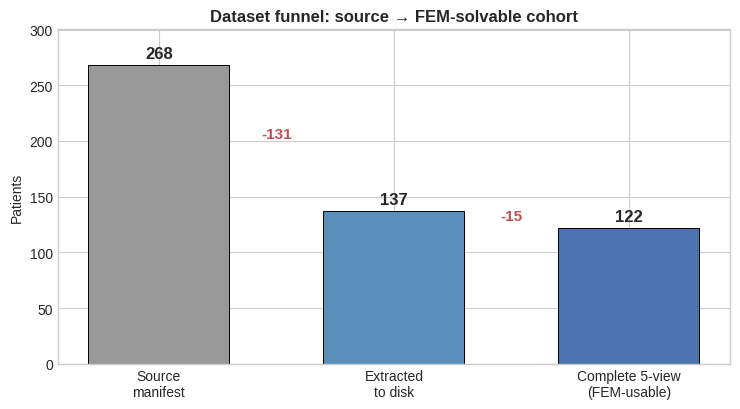

In [5]:
# --- Figure 2: data funnel ---
stages = ['Source\nmanifest', 'Extracted\nto disk', 'Complete 5-view\n(FEM-usable)']
vals   = [n_manifest, n_disk, n_complete]
fig, ax = plt.subplots(figsize=(7.5, 4.2))
bars = ax.bar(stages, vals, color=['#999999', '#5A8FBB', '#4C72B0'],
              edgecolor='black', linewidth=.7, width=.6)
ax.bar_label(bars, padding=3, fontsize=12, fontweight='bold')
for i in range(len(vals)-1):
    drop = vals[i]-vals[i+1]
    ax.annotate(f'-{drop}', xy=(i+0.5, (vals[i]+vals[i+1])/2),
                ha='center', color=MALIG_C, fontweight='bold', fontsize=11)
ax.set_ylabel('Patients'); ax.set_ylim(0, n_manifest*1.12)
ax.set_title('Dataset funnel: source → FEM-solvable cohort', fontweight='bold')
save(fig, 'fig2_data_funnel.png'); plt.show()


## 3. Per-view completeness — *why* 15 patients are dropped

A patient survives only with all 5 views. This histogram shows how many views each on-disk patient actually has; everything left of 5 is discarded.


views-per-patient (TIFF): {1: 2, 2: 3, 3: 1, 4: 9, 5: 122}
views-per-patient (mask): {1: 2, 2: 3, 3: 1, 4: 9, 5: 122}
saved → /mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/TherMAM-NeRF/results/thesis_figures/fig3_view_completeness.png


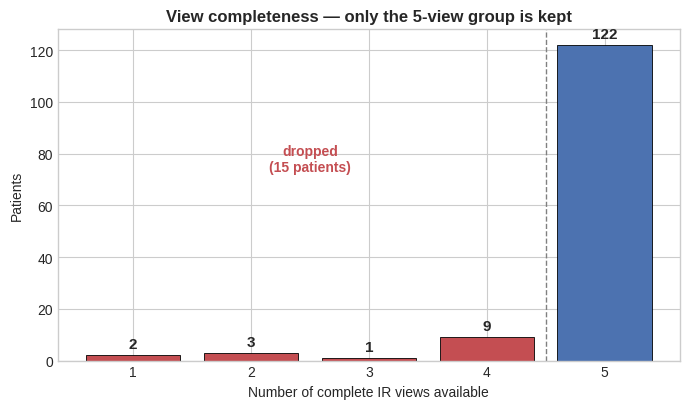

In [6]:
tiff_hist = Counter(len(v['tiffs']) for v in pd_.values())
mask_hist = Counter(len(v['masks']) for v in pd_.values())
print('views-per-patient (TIFF):', dict(sorted(tiff_hist.items())))
print('views-per-patient (mask):', dict(sorted(mask_hist.items())))

fig, ax = plt.subplots(figsize=(7, 4.2))
xs = [1, 2, 3, 4, 5]
counts = [tiff_hist.get(x, 0) for x in xs]
cols = [MALIG_C]*4 + [BENIGN_C]
b = ax.bar([str(x) for x in xs], counts, color=cols, edgecolor='black', linewidth=.6)
ax.bar_label(b, padding=3, fontsize=11, fontweight='bold')
ax.set_xlabel('Number of complete IR views available')
ax.set_ylabel('Patients')
ax.set_title('View completeness — only the 5-view group is kept', fontweight='bold')
ax.axvline(3.5, color='gray', ls='--', lw=1)
ax.text(1.5, max(counts)*0.6, f'dropped\n({sum(counts[:4])} patients)',
        ha='center', color=MALIG_C, fontweight='bold')
ax.text(4.0, max(counts)*0.6, f'kept\n({counts[4]} patients)',
        ha='center', color=BENIGN_C, fontweight='bold')
save(fig, 'fig3_view_completeness.png'); plt.show()


## 4. Clinical metadata needed by the bioheat model

The Pennes BVP needs two patient-specific temperatures:

| BVP role | Constant in code | Source |
|---|---|---|
| Chest-wall Dirichlet (core/arterial) | `T_ARTERIAL = 37 °C` | should use measured **body_temperature** |
| Skin Robin (ambient) | `T_AIR = 20 °C` | **atmospheric temperature** — measured per session by protocol, **not in our manifest** |

We plot what we *have* (body temperature, age) and flag what is *missing* (atmospheric temperature).


body_temperature : 263/268 valid  (flagged 5: zeros/sentinels)  valid range 33.0-36.9 C, mean 35.5
age_at_visit     : 267/268 valid  (flagged 1: negative/invalid)  valid range 18-89 yr, mean 54
NOTE: invalid body_temperature entries are exactly why T_arterial cannot be naively swapped to body_temperature without cleaning (they would inject 0 C chest-wall BCs).
saved → /mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/TherMAM-NeRF/results/thesis_figures/fig4_clinical_metadata.png


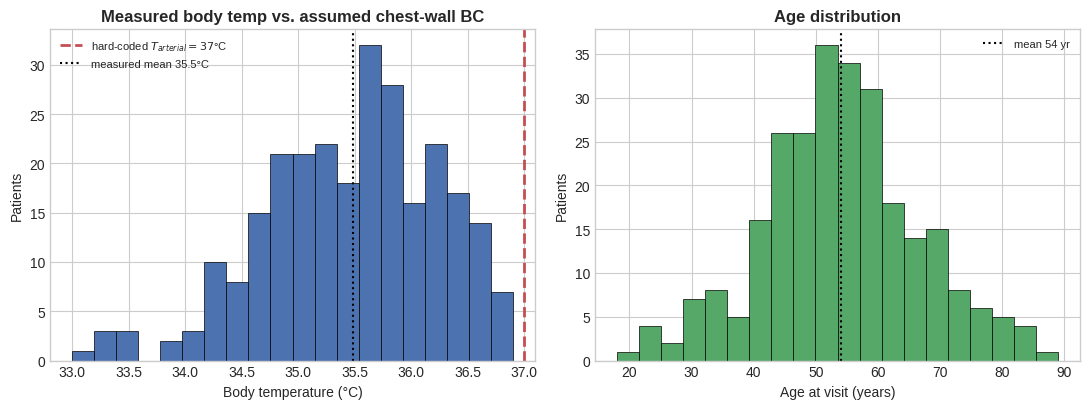

In [7]:
# numeric coercion
man['body_temperature'] = pd.to_numeric(man['body_temperature'], errors='coerce')
man['age_at_visit']     = pd.to_numeric(man['age_at_visit'],     errors='coerce')

# DATA-QUALITY GUARD: body-temp <=30 (incl 0.0) are missing-data sentinels; age<0 is a data error.
bt_all, ag_all = man['body_temperature'], man['age_at_visit']
bt_bad = int(((bt_all <= 30) | bt_all.isna()).sum())
ag_bad = int(((ag_all < 0)  | ag_all.isna()).sum())
bt = bt_all[(bt_all > 30) & (bt_all < 42)]
ag = ag_all[(ag_all >= 0) & (ag_all < 120)]
print(f'body_temperature : {bt.size}/{len(man)} valid  (flagged {bt_bad}: zeros/sentinels)  '
      f'valid range {bt.min():.1f}-{bt.max():.1f} C, mean {bt.mean():.1f}')
print(f'age_at_visit     : {ag.size}/{len(man)} valid  (flagged {ag_bad}: negative/invalid)  '
      f'valid range {ag.min():.0f}-{ag.max():.0f} yr, mean {ag.mean():.0f}')
print('NOTE: invalid body_temperature entries are exactly why T_arterial cannot be naively '
      'swapped to body_temperature without cleaning (they would inject 0 C chest-wall BCs).')

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].hist(bt, bins=20, color=BENIGN_C, edgecolor='black', linewidth=.5)
ax[0].axvline(37.0, color=MALIG_C, ls='--', lw=2, label='hard-coded $T_{arterial}=37$°C')
ax[0].axvline(bt.mean(), color='black', ls=':', lw=1.5, label=f'measured mean {bt.mean():.1f}°C')
ax[0].set_xlabel('Body temperature (°C)'); ax[0].set_ylabel('Patients')
ax[0].set_title('Measured body temp vs. assumed chest-wall BC', fontweight='bold')
ax[0].legend(fontsize=8)

ax[1].hist(ag, bins=20, color='#55A868', edgecolor='black', linewidth=.5)
ax[1].axvline(ag.mean(), color='black', ls=':', lw=1.5, label=f'mean {ag.mean():.0f} yr')
ax[1].set_xlabel('Age at visit (years)'); ax[1].set_ylabel('Patients')
ax[1].set_title('Age distribution', fontweight='bold'); ax[1].legend(fontsize=8)
save(fig, 'fig4_clinical_metadata.png'); plt.show()


## 5. FEM input checklist — does every solver input exist?

Every quantity the forward/inverse bioheat solver consumes, where it comes from, and whether we actually have it for the 122-patient cohort.


In [8]:
checklist = [
    # name, role in solver, source, status
    ('Surface vertices (3-D mesh)', 'domain geometry Ω',         'TherMAM-NeRF recon from 5 views', 'DERIVED — 122/122'),
    ('Tetrahedral volume mesh',     'FEM discretisation',        'gmsh from surface STL',           'DERIVED at runtime'),
    ('T_measured (skin IR field)',  'inverse target',            'TIFF → Celsius (5 views)',        'PRESENT — 122/122'),
    ('Segmentation masks',          'breast region for recon',   'U-Net masks (5 views)',           'PRESENT — 122/122'),
    ('Chest-wall mask',             'Dirichlet boundary Γ_wall', 'back 10% of depth (geometry)',    'DERIVED — rule-based'),
    ('k, ω_b, c_b, Q_m',            'Pennes coefficients',       'literature constants (shared)',   'FIXED (Bezerra/Mukhmetov)'),
    ('T_arterial (chest-wall BC)',  'Dirichlet value',           'should be body_temperature',      'ASSUMED 37°C (data exists!)'),
    ('T_air (skin Robin BC)',       'ambient value',             'session atmospheric temp',        'ASSUMED 20°C — MISSING in data'),
    ('h (convective coeff)',        'skin Robin BC',             'natural-convection estimate',     'ASSUMED 10 W/m²K'),
    ('Q_tumor magnitude',           'source term',               'Gautherie law from radius',       'FIXED by r (not free)'),
]
chk = pd.DataFrame(checklist, columns=['FEM input', 'Role', 'Source', 'Status'])
pd.set_option('display.max_colwidth', None)
chk


,FEM input,Role,Source,Status
0,Surface vertices (3-D mesh),domain geometry Ω,TherMAM-NeRF recon from 5 views,DERIVED — 122/122
1,Tetrahedral volume mesh,FEM discretisation,gmsh from surface STL,DERIVED at runtime
2,T_measured (skin IR field),inverse target,TIFF → Celsius (5 views),PRESENT — 122/122
3,Segmentation masks,breast region for recon,U-Net masks (5 views),PRESENT — 122/122
4,Chest-wall mask,Dirichlet boundary Γ_wall,back 10% of depth (geometry),DERIVED — rule-based
5,"k, ω_b, c_b, Q_m",Pennes coefficients,literature constants (shared),FIXED (Bezerra/Mukhmetov)
6,T_arterial (chest-wall BC),Dirichlet value,should be body_temperature,ASSUMED 37°C (data exists!)
7,T_air (skin Robin BC),ambient value,session atmospheric temp,ASSUMED 20°C — MISSING in data
8,h (convective coeff),skin Robin BC,natural-convection estimate,ASSUMED 10 W/m²K
9,Q_tumor magnitude,source term,Gautherie law from radius,FIXED by r (not free)


saved → /mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/TherMAM-NeRF/results/thesis_figures/fig5_fem_input_map.png


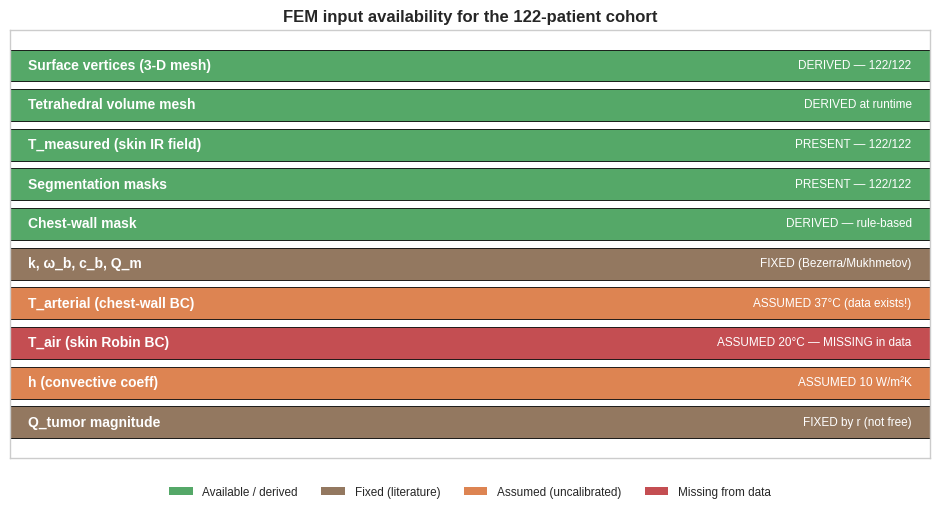

In [9]:
# --- Figure 5: FEM input availability map (green=have, amber=assumed, red=missing) ---
def cat(s):
    s=s.upper()
    if 'MISSING' in s: return ('MISSING', '#C44E52')
    if 'ASSUMED' in s: return ('ASSUMED', '#DD8452')
    if 'FIXED'   in s: return ('FIXED',   '#937860')
    return ('AVAILABLE', '#55A868')
labels, colors = zip(*[cat(s) for s in chk['Status']])
fig, ax = plt.subplots(figsize=(9.5, 5.2))
y = np.arange(len(chk))[::-1]
ax.barh(y, [1]*len(chk), color=colors, edgecolor='black', linewidth=.6)
for yi, (name, st) in zip(y, zip(chk['FEM input'], chk['Status'])):
    ax.text(0.02, yi, name, va='center', ha='left', fontsize=10, fontweight='bold', color='white')
    ax.text(0.98, yi, st, va='center', ha='right', fontsize=8.5, color='white')
ax.set_xlim(0, 1); ax.set_yticks([]); ax.set_xticks([])
ax.set_title('FEM input availability for the 122-patient cohort', fontweight='bold')
from matplotlib.patches import Patch
leg = [Patch(facecolor='#55A868', label='Available / derived'),
       Patch(facecolor='#937860', label='Fixed (literature)'),
       Patch(facecolor='#DD8452', label='Assumed (uncalibrated)'),
       Patch(facecolor='#C44E52', label='Missing from data')]
ax.legend(handles=leg, loc='lower center', bbox_to_anchor=(0.5, -0.12), ncol=4, fontsize=8.5, frameon=False)
save(fig, 'fig5_fem_input_map.png'); plt.show()


## 6. Usable-cohort class balance (the 122) + solved-so-far status

Class balance of the FEM-solvable cohort, and how many we have inverse-solved to date.


In [ ]:
usable = pd.DataFrame([{'patient_id': pid, 'label': lab} for (pid, lab) in complete])
print('Usable cohort (122):'); print(usable['label'].value_counts())

solved = set()
for c in [COHORT_CSV,
          REPO/'TherMAM-NeRF'/'results'/'femfem_gpu0_rest.csv',
          REPO/'TherMAM-NeRF'/'results'/'femfem_gpu1_rest.csv']:
    if c.exists():
        d = pd.read_csv(c)
        solved |= set(d.loc[d['final_cost'].notna(), 'patient_id'])
print(f'\nInverse-solved so far: {len(solved)} / 122')

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
uc = usable['label'].value_counts()
b = ax[0].bar(uc.index, uc.values, color=[BENIGN_C if l=='benign' else MALIG_C for l in uc.index],
              edgecolor='black', linewidth=.6)
ax[0].bar_label(b, padding=3, fontweight='bold')
ax[0].set_title('FEM-usable cohort class balance (n=122)', fontweight='bold')
ax[0].set_ylabel('Patients')

done = len(solved); todo = 122 - done
ax[1].pie([done, todo], labels=[f'solved\n{done}', f'remaining\n{todo}'],
          colors=['#55A868', '#CCCCCC'], autopct='%1.0f%%', startangle=90,
          wedgeprops=dict(edgecolor='white', linewidth=1.5))
ax[1].set_title('Inverse-solve progress', fontweight='bold')
save(fig, 'fig6_usable_and_progress.png'); plt.show()


---
### Summary for the thesis

- **268** patients in the source DMR-IR manifest (171 benign / 97 malignant).
- **137** were extracted to disk; **122** have the complete 5-view + 5-mask set required to build the 3-D breast mesh — these are the FEM-solvable cohort (**15 dropped** for missing views).
- All **geometry and IR** inputs the solver needs are present for 122/122.
- **Boundary-condition temperatures are the weak link:** `T_arterial=37 °C` ignores the measured `body_temperature` (which we *do* have), and `T_air=20 °C` is an uncalibrated guess for an atmospheric temperature the acquisition protocol measured per session but our pipeline never stored.

Figures saved to `results/thesis_figures/`.
